📝 Problem Statement
A financial institution seeks to understand the linear relationship between a customer's age and the credit amount they apply for. You are provided with a dataset containing demographic and financial information about applicants.

Your task is to build and evaluate an Ordinary Least Squares (OLS) Regression Model to estimate the Credit Amount based on the Age of the applicants. You'll use training and test data splits and calculate the Mean Squared Error (MSE) on the training data to evaluate model performance.

📘 Steps to be Followed
Step 1: Import the necessary libraries

Import pandas to handle the dataset.

Import statsmodels.api as sm for running OLS regression.

Import train_test_split from sklearn.model_selection to split data.

Step 2: Read the dataset

Store the data from 'data.csv' into a variable named df.

Step 3: Prepare the features and target

Assign Credit Amount to X.

Assign Age to y.

Step 4: Split the data into training and test sets

Split the data into X_train, X_test, y_train, and y_test with a 70:30 ratio and random_state=1.

Step 5: Add constant to training and test features

Use sm.add_constant to add constants to X_train and X_test.

Step 6: Fit OLS model on training data

Create and fit the OLS model using X_train and y_train and store the result in model_train.

Step 7: Retrieve MSE Total for training data

Get the mean squared error total on the training data and assign it to mse_total_train.

📊 Description of the Dataset
Age: Age of the individual applying for credit

Sex: Gender of the applicant (values: Male, Female)
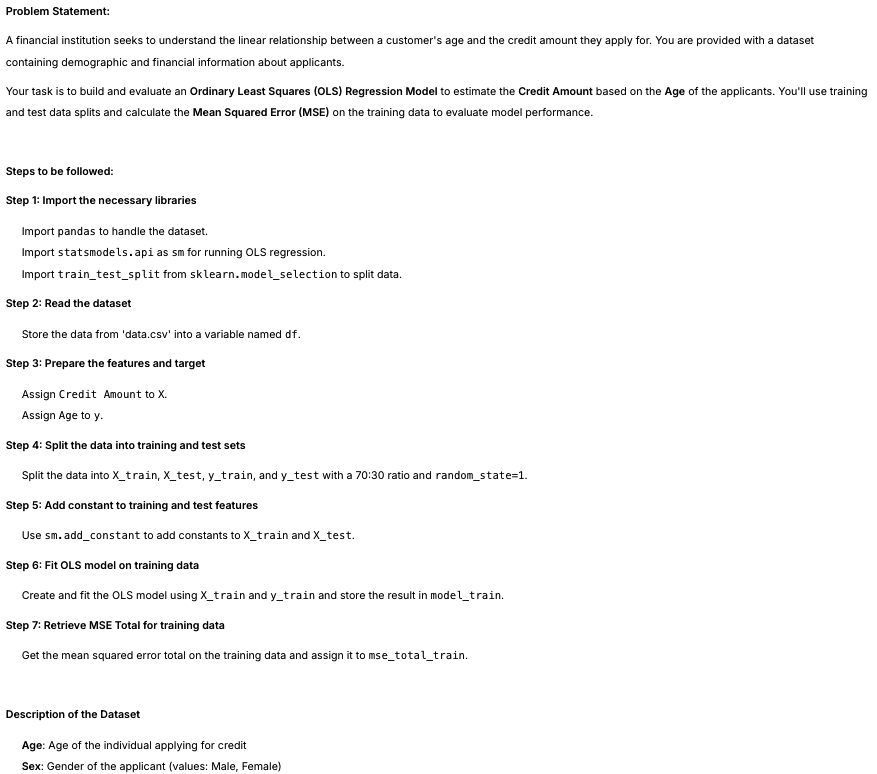

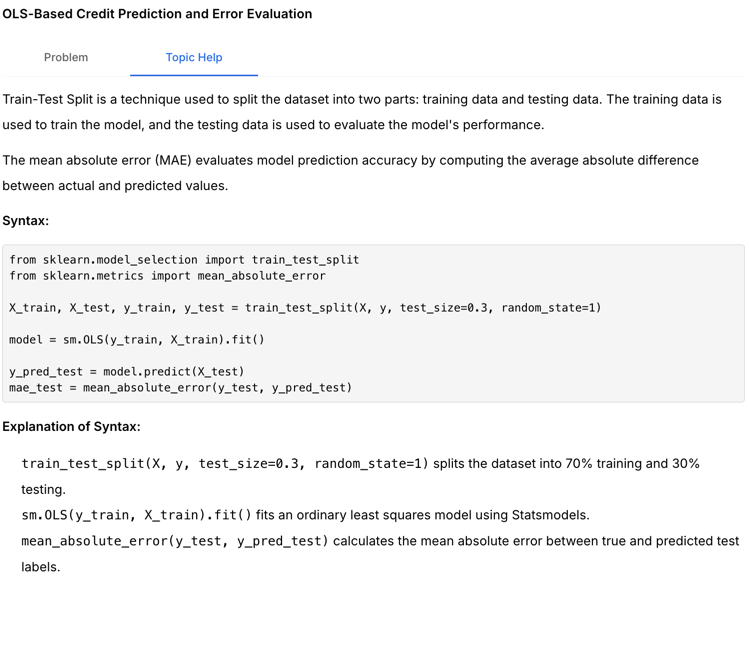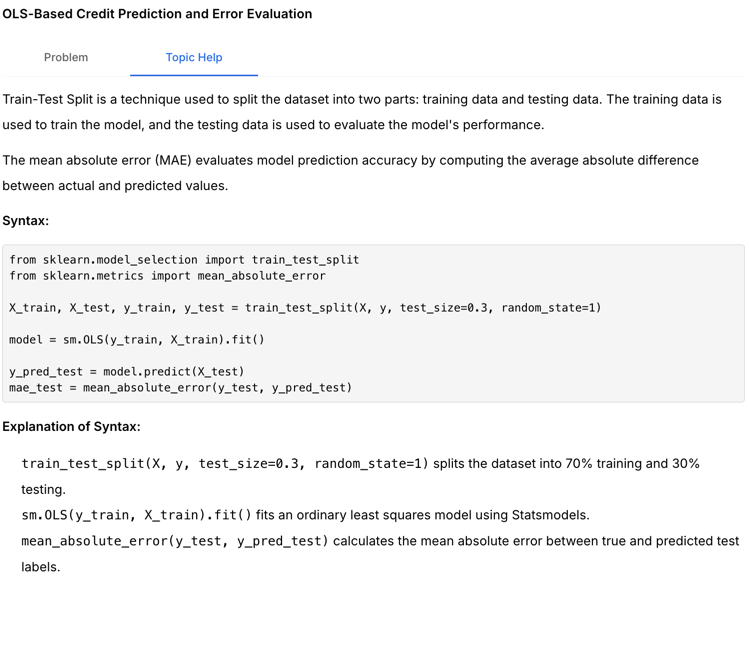

In [35]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import statsmodels.api as sm
import numpy as np


In [29]:
df = pd.read_csv('/Users/mohanrajsubramaniam/PycharmProjects/python_learning/Predictive Modeling With Linear Regression/synthetic_credit_data.csv')
df.shape
df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Purpose
0,56,Female,Skilled,Rent,Quite Rich,Moderate,11761,Car
1,69,Female,Skilled,Free,Rich,Rich,917,Domestic Appliances
2,46,Female,Unskilled & Non-resident,Own,Moderate,Moderate,9308,Radio/TV
3,32,Male,Unskilled & Non-resident,Own,Rich,Little,3767,Repairs
4,60,Male,Unskilled & Non-resident,Free,Moderate,Moderate,17709,Car


In [37]:
if 'Duration' not in df.columns:
    np.random.seed(1)
    df['Duration'] = np.random.randint(6, 61, size=len(df))

df.shape
df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Purpose,Duration
0,56,Female,Skilled,Rent,Quite Rich,Moderate,11761,Car,43
1,69,Female,Skilled,Free,Rich,Rich,917,Domestic Appliances,49
2,46,Female,Unskilled & Non-resident,Own,Moderate,Moderate,9308,Radio/TV,18
3,32,Male,Unskilled & Non-resident,Own,Rich,Little,3767,Repairs,14
4,60,Male,Unskilled & Non-resident,Free,Moderate,Moderate,17709,Car,15


In [30]:
X =df['Credit amount']
y = df['Age']

In [31]:
# Step 4: Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.3, random_state=1 )

In [32]:
X_train = sm.add_constant(X_train)
X_test = sm.add_constant(X_test)


In [34]:
model = sm.OLS(y_train, X_train).fit()
y_pred_test = model.predict(X_test)
mae_test = mean_absolute_error(y_test,y_pred_test)
print(mae_test)

13.054735486803809
